In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler,LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats



## LAB-2

### 1.LOAD DATA AND INSPECT

In [5]:
df = pd.read_csv("apartments_for_rent_classified_10K.csv", 
                  encoding='cp1252', 
                  on_bad_lines='skip',
                  engine='python',
                  sep=';')

In [6]:
display (df.head())
print(df.shape)
print(df.info())


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


(10000, 22)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   category       10000 non-null  str    
 2   title          10000 non-null  str    
 3   body           10000 non-null  str    
 4   amenities      6451 non-null   str    
 5   bathrooms      9966 non-null   float64
 6   bedrooms       9993 non-null   float64
 7   currency       10000 non-null  str    
 8   fee            10000 non-null  str    
 9   has_photo      10000 non-null  str    
 10  pets_allowed   5837 non-null   str    
 11  price          10000 non-null  int64  
 12  price_display  10000 non-null  str    
 13  price_type     10000 non-null  str    
 14  square_feet    10000 non-null  int64  
 15  address        6673 non-null   str    
 16  cityname       9923 non-null   str    
 17  state          9923 non-null   str    
 18  latitu

### 2.HANDLE MISSING VALUES

In [7]:
df['amenities'] = df['amenities'].fillna('None')
df['address'] = df['address'].fillna ('Unknown')
df['pets_allowed'] = df['pets_allowed'].fillna('Unknown')
df = df.dropna(subset=['cityname', 'state'])
df['bathrooms'] =df['bathrooms'].fillna(df['bathrooms'].median())
df['bedrooms'] =df['bedrooms'].fillna(df['bedrooms'].median())

print (df.shape)
print (df.isnull().sum())





(9923, 22)
id               0
category         0
title            0
body             0
amenities        0
bathrooms        0
bedrooms         0
currency         0
fee              0
has_photo        0
pets_allowed     0
price            0
price_display    0
price_type       0
square_feet      0
address          0
cityname         0
state            0
latitude         0
longitude        0
source           0
time             0
dtype: int64


### Data Cleaning

- **Categorical columns** (`amenities`, `address`, `pets_allowed`): missing values filled with placeholder labels ("None" / "Unknown") instead of dropping, since these columns had a large amount of missing data.
- **Location columns** (`cityname`, `state`, `latitude`, `longitude`): rows with missing values dropped, since these are important for location-based analysis and only a small number of rows were affected.
- **Numeric columns** (`bathrooms`, `bedrooms`): missing values filled with the **median**, since only a few values were missing.
- **Result:** dataset now has no missing values.

### 3.Encode Categorical Data

In [8]:
print (df.dtypes)

id                 int64
category             str
title                str
body                 str
amenities            str
bathrooms        float64
bedrooms         float64
currency             str
fee                  str
has_photo            str
pets_allowed         str
price              int64
price_display        str
price_type           str
square_feet        int64
address              str
cityname             str
state                str
latitude         float64
longitude        float64
source               str
time               int64
dtype: object


In [9]:
print(df['fee'].unique())
print(df['has_photo'].unique())
print(df['pets_allowed'].unique())
print(df['price_type'].unique())
print(df['category'].unique())


<StringArray>
['No']
Length: 1, dtype: str
<StringArray>
['Thumbnail', 'Yes', 'No']
Length: 3, dtype: str
<StringArray>
['Unknown', 'Cats,Dogs', 'Cats', 'Dogs']
Length: 4, dtype: str
<StringArray>
['Monthly', 'Weekly', 'Monthly|Weekly']
Length: 3, dtype: str
<StringArray>
['housing/rent/apartment', 'housing/rent/home', 'housing/rent/short_term']
Length: 3, dtype: str


In [10]:
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols].nunique()

C:\Users\wasia\AppData\Local\Temp\ipykernel_18740\3925099768.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


category            3
title            9274
body             9884
amenities        2248
currency            1
fee                 1
has_photo           3
pets_allowed        4
price_display    1725
price_type          3
address          6593
cityname         1574
state              51
source             12
dtype: int64

In [11]:
df = df.drop(columns=['currency', 'fee', 'title', 'body', 'amenities', 'price_display', 'address','latitude','longitude','time'], errors='ignore')

In [12]:

print (df.columns.tolist())
print (df.nunique())
print (df.info())
display(df.head())


['id', 'category', 'bathrooms', 'bedrooms', 'has_photo', 'pets_allowed', 'price', 'price_type', 'square_feet', 'cityname', 'state', 'source']
id              9923
category           3
bathrooms         14
bedrooms          10
has_photo          3
pets_allowed       4
price           1724
price_type         3
square_feet     1734
cityname        1574
state             51
source            12
dtype: int64
<class 'pandas.DataFrame'>
Index: 9923 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            9923 non-null   int64  
 1   category      9923 non-null   str    
 2   bathrooms     9923 non-null   float64
 3   bedrooms      9923 non-null   float64
 4   has_photo     9923 non-null   str    
 5   pets_allowed  9923 non-null   str    
 6   price         9923 non-null   int64  
 7   price_type    9923 non-null   str    
 8   square_feet   9923 non-null   int64  
 9   cityname      9923 non-n

,id,category,bathrooms,bedrooms,has_photo,pets_allowed,price,price_type,square_feet,cityname,state,source
0,5668626895,housing/rent/apartment,1.0,0.0,Thumbnail,Unknown,790,Monthly,101,Washington,DC,RentLingo
1,5664597177,housing/rent/apartment,1.0,1.0,Thumbnail,Unknown,425,Monthly,106,Evansville,IN,RentLingo
2,5668626833,housing/rent/apartment,1.0,0.0,Thumbnail,Unknown,1390,Monthly,107,Arlington,VA,RentLingo
3,5659918074,housing/rent/apartment,1.0,0.0,Thumbnail,Unknown,925,Monthly,116,Seattle,WA,RentLingo
4,5668626759,housing/rent/apartment,1.0,0.0,Thumbnail,Unknown,880,Monthly,125,Arlington,VA,RentLingo


In [13]:
df = pd.get_dummies(df, columns=['category', 'has_photo', 'pets_allowed', 'price_type'], drop_first=True)

print(df.shape)
display(df.head())

(9923, 17)


,id,bathrooms,bedrooms,price,square_feet,cityname,state,source,category_housing/rent/home,category_housing/rent/short_term,has_photo_Thumbnail,has_photo_Yes,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_Unknown,price_type_Monthly|Weekly,price_type_Weekly
0,5668626895,1.0,0.0,790,101,Washington,DC,RentLingo,False,False,True,False,False,False,True,False,False
1,5664597177,1.0,1.0,425,106,Evansville,IN,RentLingo,False,False,True,False,False,False,True,False,False
2,5668626833,1.0,0.0,1390,107,Arlington,VA,RentLingo,False,False,True,False,False,False,True,False,False
3,5659918074,1.0,0.0,925,116,Seattle,WA,RentLingo,False,False,True,False,False,False,True,False,False
4,5668626759,1.0,0.0,880,125,Arlington,VA,RentLingo,False,False,True,False,False,False,True,False,False


### explanation pending  

### 4. Normalize and Scale Numeric Columns

In [14]:
num_cols = ['bathrooms', 'bedrooms', 'price', 'square_feet']

scaler_std = StandardScaler()
df_std = df.copy()
df_std[num_cols] = scaler_std.fit_transform(df_std[num_cols])

# Normalization: range [0, 1]

scaler_minmax = MinMaxScaler()
df_norm = df.copy()
df_norm[num_cols] = scaler_minmax.fit_transform(df_norm[num_cols])

print("Summary statistics after scaling:")
print("Standardized Data Stats:")

display(df_std[num_cols].describe().round(3))

print("\nNormalized Data Stats:")
display(df_norm[num_cols].describe().round(3))

display(df.head().round(3))

Summary statistics after scaling:
Standardized Data Stats:


,bathrooms,bedrooms,price,square_feet
count,9923.000,9923.000,9923.000,9923.000
mean,-0.000,-0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000
min,-0.616,-1.851,-1.193,-1.286
25%,-0.616,-0.790,-0.498,-0.452
50%,-0.616,0.271,-0.200,-0.218
75%,1.008,0.271,0.194,0.234
max,11.568,7.699,47.320,59.426



Normalized Data Stats:


,bathrooms,bedrooms,price,square_feet
count,9923.000,9923.000,9923.000,9923.000
mean,0.051,0.194,0.025,0.021
std,0.082,0.105,0.021,0.016
min,0.000,0.000,0.000,0.000
25%,0.000,0.111,0.014,0.014
50%,0.000,0.222,0.020,0.018
75%,0.133,0.222,0.029,0.025
max,1.000,1.000,1.000,1.000


,id,bathrooms,bedrooms,price,square_feet,cityname,state,source,category_housing/rent/home,category_housing/rent/short_term,has_photo_Thumbnail,has_photo_Yes,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_Unknown,price_type_Monthly|Weekly,price_type_Weekly
0,5668626895,1.0,0.0,790,101,Washington,DC,RentLingo,False,False,True,False,False,False,True,False,False
1,5664597177,1.0,1.0,425,106,Evansville,IN,RentLingo,False,False,True,False,False,False,True,False,False
2,5668626833,1.0,0.0,1390,107,Arlington,VA,RentLingo,False,False,True,False,False,False,True,False,False
3,5659918074,1.0,0.0,925,116,Seattle,WA,RentLingo,False,False,True,False,False,False,True,False,False
4,5668626759,1.0,0.0,880,125,Arlington,VA,RentLingo,False,False,True,False,False,False,True,False,False


### Feature Scaling (Standardization vs. Normalization)

We experimented with two primary scaling techniques on our numeric columns (`bathrooms`, `bedrooms`, `price`, `square_feet`):
1. **Standardization (`StandardScaler`)**: Centers the data around a mean of 0 with a standard deviation of 1.
2. **Normalization (`MinMaxScaler`)**: Compresses all data values strictly between the range of 0 and 1.

#### Why Standardization is the Better Choice for This Dataset:
* **The Outlier Squash Problem:** Our dataset contains extreme luxury apartments (massive outliers in `price` and `square_feet`). Under Normalization, forcing these huge maximums to `1.0` squashes 75% of our regular data points into a tiny fraction between `0.0` and `0.01`, making them indistinguishable.
* **Outlier Resilience:** Standardization does not have strict boundaries. It allows regular apartments to stay naturally clustered around `0` while letting the extreme luxury properties safely shoot up to high values (like `47.3` and `59.4`) without ruining the distribution of the rest of the data.


### Mathematical Formulas for Feature Scaling

#### 1. StandardScaler (Standardization)
Standardization shifts the data to have a mean of 0 and a standard deviation of 1 using the following formula:

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

Where:
* $x$ = Original value
* $\mu$ = Mean (average) of the column
* $\sigma$ = Standard deviation of the column

---

#### 2. MinMaxScaler (Normalization)
Normalization rescales the data so that all values fit strictly within a specified range (by default, 0 to 1) using the following formula:

$$x_{\text{scaled}} = \frac{x - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}$$

Where:
* $x$ = Original value
* $x_{\text{min}}$ = Minimum value in the column
* $x_{\text{max}}$ = Maximum value in the column



### 5. Remove Duplicates

In [15]:

before = df_std.shape[0]

df_clean = df_std.drop_duplicates()

after = df_clean.shape[0]

print(f"Removed {before - after} duplicate rows.")
print(f"New dataset shape: {df_clean.shape}")

Removed 0 duplicate rows.
New dataset shape: (9923, 17)


## Lab 3: Exploratory Data Analysis (EDA)

In [16]:
df_raw = pd.read_csv("apartments_for_rent_classified_10K.csv", 
                     encoding='cp1252', 
                     on_bad_lines='skip',
                     engine='python',
                     sep=';')

df_raw['amenities'] = df_raw['amenities'].fillna('None')
df_raw['address'] = df_raw['address'].fillna('Unknown')
df_raw['pets_allowed'] = df_raw['pets_allowed'].fillna('Unknown')
df_raw = df_raw.dropna(subset=['cityname', 'state'])
df_raw['bathrooms'] = df_raw['bathrooms'].fillna(df_raw['bathrooms'].median())
df_raw['bedrooms'] = df_raw['bedrooms'].fillna(df_raw['bedrooms'].median())

df_raw = df_raw.drop(columns=['currency', 'fee', 'title', 'body', 'amenities', 'price_display', 'address','latitude','longitude','time'], errors='ignore')

df_unscaled = pd.get_dummies(df_raw, columns=['category', 'has_photo', 'pets_allowed', 'price_type'], drop_first=True)


df_unscaled = df_unscaled.drop_duplicates()

print("Perfect! Structure matches completely.")
print("Columns in df_unscaled:", df_unscaled.columns.tolist())
print (df_unscaled.shape)
display (df_unscaled.head())
display(df_unscaled[['bathrooms', 'bedrooms', 'price', 'square_feet']].head())

Perfect! Structure matches completely.
Columns in df_unscaled: ['id', 'bathrooms', 'bedrooms', 'price', 'square_feet', 'cityname', 'state', 'source', 'category_housing/rent/home', 'category_housing/rent/short_term', 'has_photo_Thumbnail', 'has_photo_Yes', 'pets_allowed_Cats,Dogs', 'pets_allowed_Dogs', 'pets_allowed_Unknown', 'price_type_Monthly|Weekly', 'price_type_Weekly']
(9923, 17)


,id,bathrooms,bedrooms,price,square_feet,cityname,state,source,category_housing/rent/home,category_housing/rent/short_term,has_photo_Thumbnail,has_photo_Yes,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_Unknown,price_type_Monthly|Weekly,price_type_Weekly
0,5668626895,1.0,0.0,790,101,Washington,DC,RentLingo,False,False,True,False,False,False,True,False,False
1,5664597177,1.0,1.0,425,106,Evansville,IN,RentLingo,False,False,True,False,False,False,True,False,False
2,5668626833,1.0,0.0,1390,107,Arlington,VA,RentLingo,False,False,True,False,False,False,True,False,False
3,5659918074,1.0,0.0,925,116,Seattle,WA,RentLingo,False,False,True,False,False,False,True,False,False
4,5668626759,1.0,0.0,880,125,Arlington,VA,RentLingo,False,False,True,False,False,False,True,False,False


,bathrooms,bedrooms,price,square_feet
0,1.0,0.0,790,101
1,1.0,1.0,425,106
2,1.0,0.0,1390,107
3,1.0,0.0,925,116
4,1.0,0.0,880,125


### 1. Visualize distribution 


#### Univariate Analysis

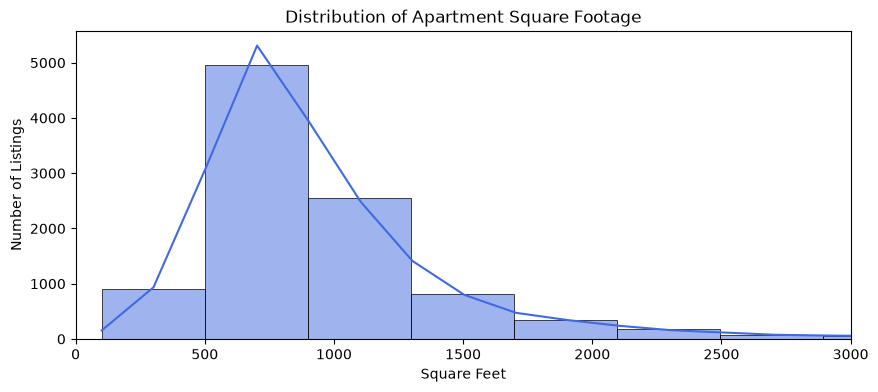

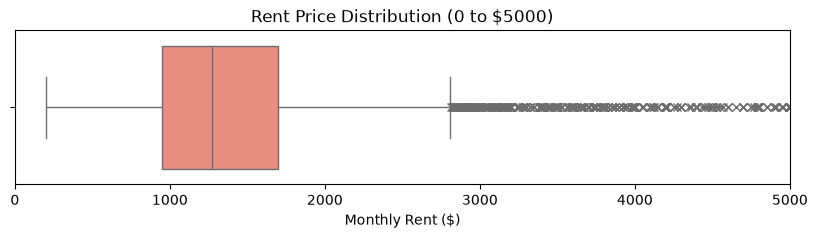

In [17]:
plt.figure(figsize=(10, 4))
sns.histplot(df_unscaled['square_feet'], kde=True, bins=100, color='royalblue')
plt.xlim(0, 3000) # Limits view to where the majority of normal apartments are
plt.title("Distribution of Apartment Square Footage")
plt.xlabel("Square Feet")
plt.ylabel("Number of Listings")
plt.show()

# 2. Boxplot for Rent Price (Zoomed)
plt.figure(figsize=(10, 2))
sns.boxplot(x=df_unscaled['price'], color='salmon', flierprops={"marker": "x"})
plt.xlim(0, 5000)
plt.title("Rent Price Distribution (0 to $5000)")
plt.xlabel("Monthly Rent ($)")
plt.show()

#### Bivariate & Multivariate Analysis (Relationships)

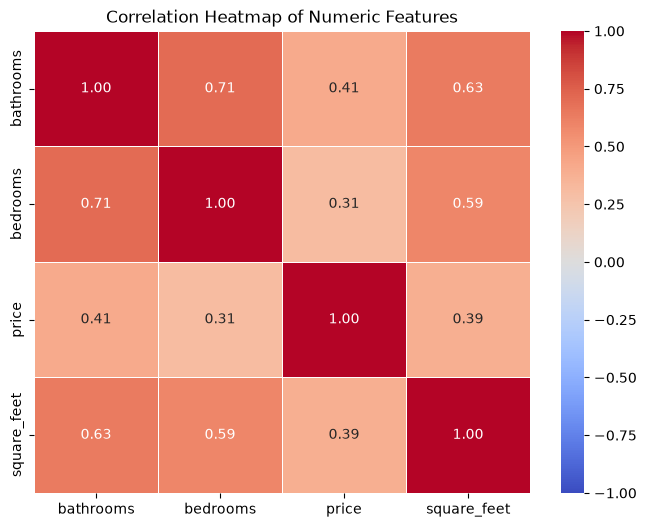

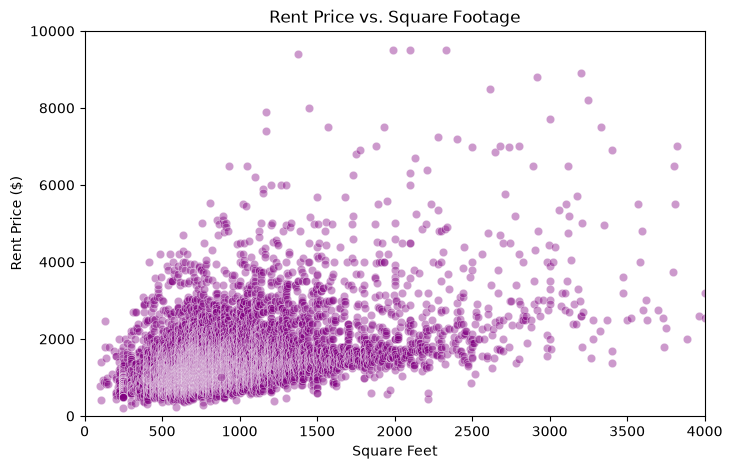

In [18]:
# 3. Correlation Heatmap
plt.figure(figsize=(8, 6))
# numeric_only=True prevents pandas from crashing on text columns like 'cityname'
corr_matrix = df_unscaled[['bathrooms', 'bedrooms', 'price', 'square_feet']].corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# 4. Scatter Plot: Size vs. Price
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_unscaled, x='square_feet', y='price', alpha=0.4, color='purple')
plt.xlim(0, 4000) # Zooming in to ignore the 50,000 sq ft data entry errors
plt.ylim(0, 10000)
plt.title("Rent Price vs. Square Footage")
plt.xlabel("Square Feet")
plt.ylabel("Rent Price ($)")
plt.show()

#### Categorical Analysis (Location & Policies)

C:\Users\wasia\AppData\Local\Temp\ipykernel_18740\2745673682.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='state', data=df_unscaled, order=top_10_states, palette='viridis')


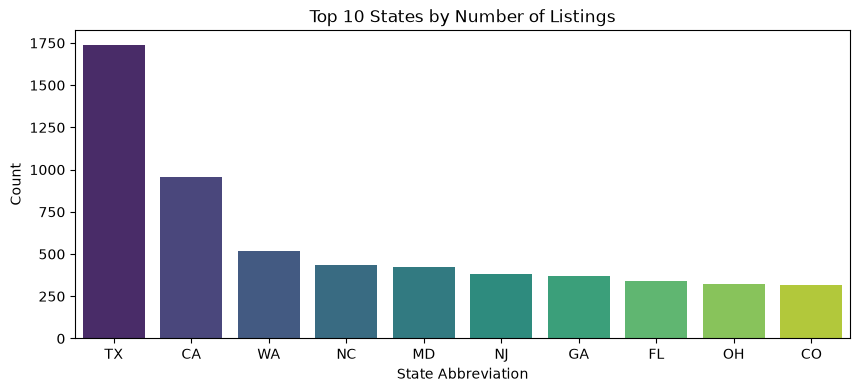

C:\Users\wasia\AppData\Local\Temp\ipykernel_18740\2745673682.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='pets_allowed', y='price', data=df_raw.drop_duplicates(), palette='Set2')


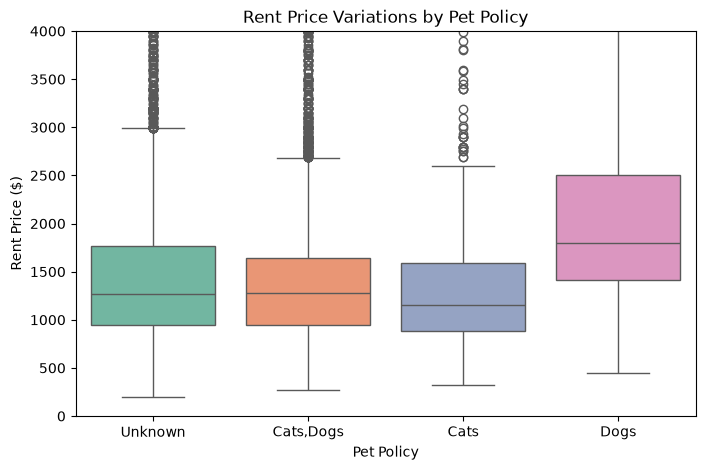

In [19]:
# 5. Count Plot for Top 10 States
plt.figure(figsize=(10, 4))
top_10_states = df_unscaled['state'].value_counts().iloc[:10].index
sns.countplot(x='state', data=df_unscaled, order=top_10_states, palette='viridis')
plt.title("Top 10 States by Number of Listings")
plt.xlabel("State Abbreviation")
plt.ylabel("Count")
plt.show()

# 6. Grouped Boxplot: Pets Allowed vs. Price
# 6. Grouped Boxplot: Pets Allowed vs. Price
# Using df_raw to access the un-encoded categorical text!
plt.figure(figsize=(8, 5))
sns.boxplot(x='pets_allowed', y='price', data=df_raw.drop_duplicates(), palette='Set2')
plt.ylim(0, 4000) # Zoom in to see the box distributions clearly
plt.title("Rent Price Variations by Pet Policy")
plt.xlabel("Pet Policy")
plt.ylabel("Rent Price ($)")
plt.show()

#### 1. Univariate Analysis (Distributions)
* **Right-Skewed Data:** Both rent `price` and `square_feet` are heavily right-skewed. The vast majority of apartments cluster at a more affordable, standard size, while a long tail represents rare, massive properties.
* **Extreme Outliers:** Boxplots successfully flagged significant statistical outliers. These highlight ultra-luxury listings (or potential data-entry errors) that sit far above standard market rates.

#### 2. Bivariate & Multivariate Analysis (Relationships)
* **Strong Positive Correlation:** The correlation heatmap and scatter plots confirm a direct, strong positive relationship between `square_feet` and `price`. As physical size increases, the rent price predictably rises.
* **Feature Interactions:** Other structural features, like `bedrooms` and `bathrooms`, naturally track closely with square footage, which is important to note for preventing multicollinearity in future predictive models.

#### 3. Categorical Analysis (Location & Policies)
* **Geographic Bias:** The count plot of the top 10 states reveals that the dataset is highly concentrated in specific regions rather than being evenly distributed across the country.
* **Policy Impact:** Grouping price by `pets_allowed` allows us to visually inspect the median rent differences, indicating whether pet-friendly properties command a market premium.

### 2. Outlier detecion (Z score method)

In [20]:
numeric_cols = ['bathrooms', 'bedrooms', 'price', 'square_feet']

# 2. Calculate the absolute Z-scores for these columns
z_scores = np.abs(stats.zscore(df_unscaled[numeric_cols]))

outliers_z_array = (z_scores > 3).sum(axis=0)

# Wrap it in a pandas Series to add the column names
outliers_z = pd.Series(outliers_z_array, index=numeric_cols)

print("Outliers per column (Z-Score Method):")
print(outliers_z)


Outliers per column (Z-Score Method):
bathrooms      138
bedrooms       109
price          122
square_feet    105
dtype: int64


### The IQR method 

In [21]:
Q1 = df_unscaled[numeric_cols].quantile(0.25)
Q3 = df_unscaled[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = ((df_unscaled[numeric_cols] < lower_bound) | (df_unscaled[numeric_cols] > upper_bound)).sum(axis=0)

print("Outliers per column (IQR Method):")
print(outliers_iqr)

Outliers per column (IQR Method):
bathrooms       72
bedrooms       510
price          613
square_feet    619
dtype: int64


### Outlier Detection: Z-Score vs. IQR Method

After running both the Z-Score and Interquartile Range (IQR) methods to detect outliers, there is a significant difference in the results:
* **Z-Score Method:** Detected very few outliers (roughly 100-140 per column).
* **IQR Method:** Detected significantly more (over 600 for `price` and `square_feet`).

#### Which method is better for this dataset?
**The IQR Method is the superior choice for this dataset.**  Why?
1. **The Flaw of Z-Score Here:** The Z-Score method assumes the data follows a perfect normal distribution (a symmetrical bell curve). Because real estate data is heavily **right-skewed**, the few ultra-expensive apartments drag the overall *mean* (average) and *standard deviation* significantly higher. Since the Z-score uses these inflated metrics as its baseline, it becomes "blind" to many actual outliers, letting them slip through the cracks.
2. **The Strength of IQR Here:** The IQR method uses percentiles (medians) rather than averages. It looks at the actual physical middle of the data (the 25th to 75th percentiles) and builds a boundary from there. Because it is highly resistant to skewed data and extreme values, it provides a much more accurate threshold for identifying luxury outliers in real-world housing markets.

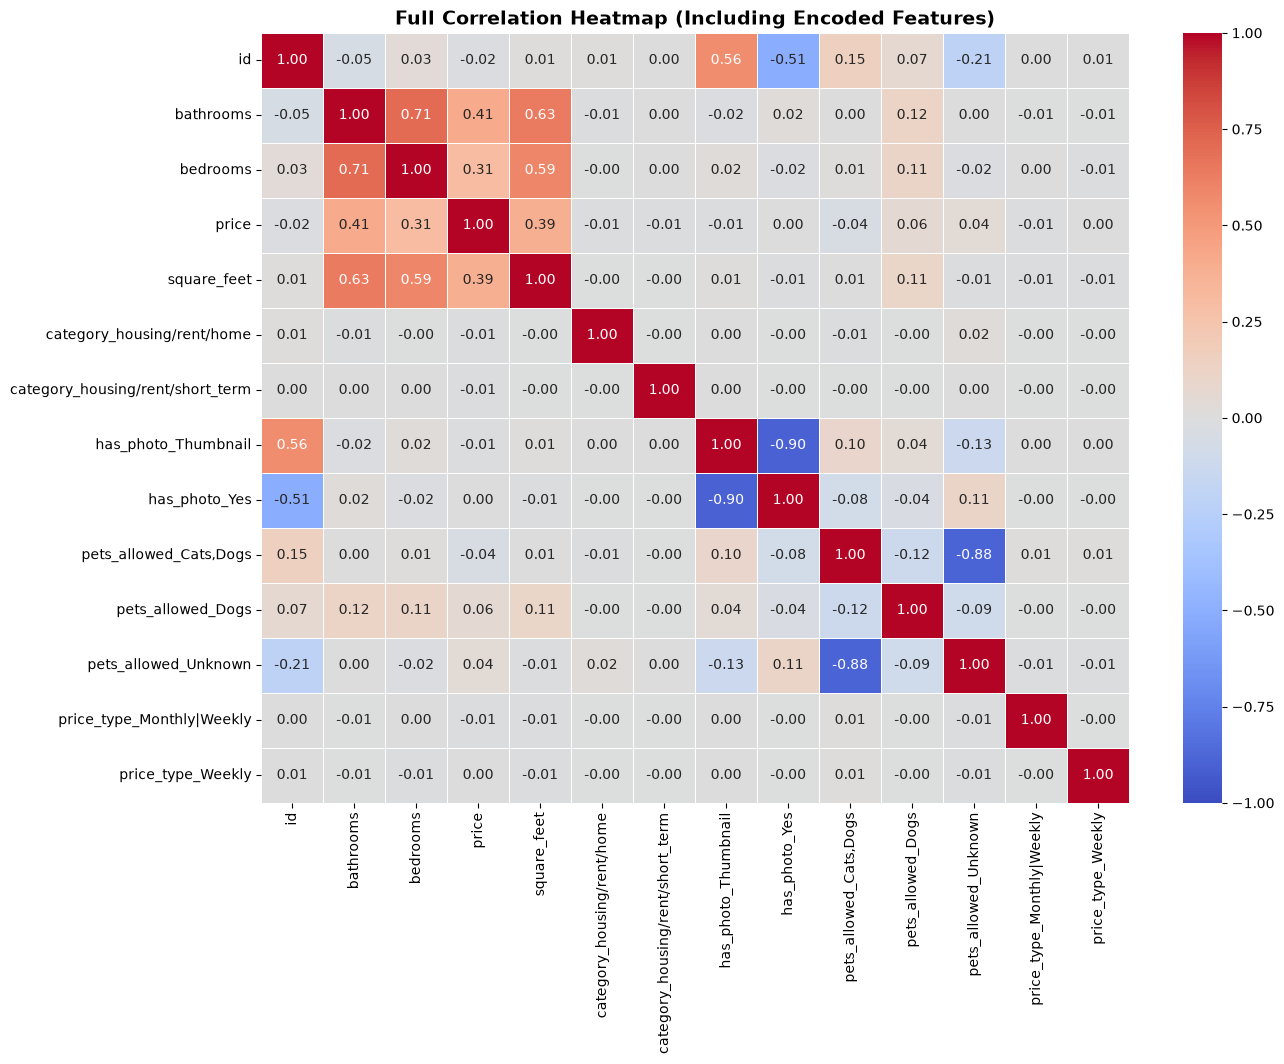

In [22]:
df_encoded_numeric = df_unscaled.select_dtypes(include=['number', 'bool'])

corr_matrix_full = df_encoded_numeric.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix_full, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Full Correlation Heatmap (Including Encoded Features)", fontsize=14, fontweight='bold')
plt.show()


#### Exercise 4: Strong and Weak Correlations

##### A. Strong Correlations
* **`square_feet` and `price`:** High positive correlation. Larger apartments directly drive up rental costs.
* **`bedrooms` and `bathrooms`:** High positive correlation. More bedrooms naturally scale with more bathrooms due to standard housing design.

##### B. Weak Correlations
* **`price_type_Weekly` and `bathrooms`:** Near-zero correlation. Choosing a weekly payment structure has no relation to how many bathrooms a property has.
* **`has_photo_Yes` and `bedrooms`:** Near-zero correlation. Listing a photo online is independent of the number of bedrooms in the apartment.

---

#### Exercise 5: Interpretation of Relationships

* **Size Rules the Market:** The strong upward trend in our data confirms that physical square footage is the primary factor driving rent prices.
* **Multicollinearity Risk:** Because `bedrooms` and `bathrooms` track so closely together, using both blindly in a predictive model might cause redundant data issues (multicollinearity).
* **Operational Independence:** Marketing features (like photos) and billing features (like weekly rent types) do not depend on the physical size or layout of the apartment.

## Lab 4: Mining Frequent Patterns and Association Rules



In [ ]:
import os
import pandas as pd
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

data_path = os.path.join("data", "Online Retail.xlsx") 

print("Loading dataset from local folder...")
df = pd.read_excel(data_path)
print(f"Dataset loaded successfully! Initial shape: {df.shape}")

# 2. DATA CLEANING & TRANSFORMATION
print("\nPreprocessing data...")
# Strip trailing spaces from descriptions and drop rows missing item descriptions or invoice numbers
df['Description'] = df['Description'].str.strip()
df.dropna(subset=['Description', 'InvoiceNo'], inplace=True)

# Coerce InvoiceNo to string and filter out cancellations (Invoices starting with 'C')
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df = df[~df['InvoiceNo'].str.startswith('C')]

# OPTIONAL SPEEDUP: The full dataset can be quite heavy for Apriori. 
# Filtering for a specific high-volume market (like France) makes it run incredibly fast.
# Comment out the next line if you want to run it on the entire global dataset!
df = df[df['Country'] == 'France']

# 3. CREATE THE TRANSACTION MATRIX (Market Basket)
# We group by InvoiceNo and Description, sum the quantities, and pivot the table
basket = (df.groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('InvoiceNo'))

# Convert quantities to simple True/False values (1 if bought, 0 if not)
def encode_units(x):
    return x > 0

basket_sets = basket.map(encode_units)
print(f"Transaction matrix built. Shape: {basket_sets.shape} (Invoices x Unique Items)")

print("\nRunning Apriori algorithm...")
frequent_itemsets_apriori = apriori(basket_sets, min_support=0.07, use_colnames=True)
print(f"Apriori found {len(frequent_itemsets_apriori)} frequent itemsets.")

# 5. RUN FP-GROWTH (For algorithm comparison)
print("Running FP-Growth algorithm...")
frequent_itemsets_fpgrowth = fpgrowth(basket_sets, min_support=0.07, use_colnames=True)
print(f"FP-Growth found {len(frequent_itemsets_fpgrowth)} frequent itemsets.")

# 6. GENERATE ASSOCIATION RULES
print("\nDeriving association rules...")
# We use the itemsets from FP-Growth (they are identical to Apriori) with a confidence threshold
rules = association_rules(frequent_itemsets_fpgrowth, metric="confidence", min_threshold=0.7)

# Sort rules by Lift to bubble up the most relevant patterns
rules = rules.sort_values(by="lift", ascending=False)

# 7. DISPLAY RESULTS
print("\n" + "="*40 + " TOP 10 ASSOCIATION RULES " + "="*40)
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Loading dataset from local folder...
Dataset loaded successfully! Initial shape: (541909, 8)

Preprocessing data...
Transaction matrix built. Shape: (392, 1563) (Invoices x Unique Items)

Running Apriori algorithm...
Apriori found 90 frequent itemsets.
Running FP-Growth algorithm...
FP-Growth found 90 frequent itemsets.

Deriving association rules...

======================================== TOP 10 ASSOCIATION RULES ========================================
                                          antecedents  \
16              frozenset({ALARM CLOCK BAKELIKE RED})   
14   frozenset({POSTAGE, ALARM CLOCK BAKELIKE GREEN})   
10            frozenset({ALARM CLOCK BAKELIKE GREEN})   
9               frozenset({ALARM CLOCK BAKELIKE RED})   
13     frozenset({POSTAGE, ALARM CLOCK BAKELIKE RED})   
17            frozenset({ALARM CLOCK BAKELIKE GREEN})   
12             frozenset({ALARM CLOCK BAKELIKE PINK})   
11              frozenset({ALARM CLOCK BAKELIKE RED})   
49         frozenset({SET/

# Market Basket Analysis — Output Explanation

This document provides a simple, structured breakdown of the output generated by the Association Rule Mining script using the **Apriori** and **FP-Growth** algorithms on the Online Retail dataset (filtered for the France market).

---

## 1. Execution Summary & Shapes

* **Initial Shape `(541909, 8)`:** The raw global dataset contains over 541,000 transaction rows and 8 features.
* **Transaction Matrix Shape `(392, 1563)`:** After cleaning the data (removing cancellations/nulls) and filtering exclusively for **France**, the dataset was reshaped. This means the matrix analyzes **392 unique invoices (baskets)** across **1,563 unique items**.
* **Algorithm Performance:** Both Apriori and FP-Growth discovered exactly **90 frequent itemsets** using a minimum support threshold of `0.07` (meaning the items appear in at least 7% of all French transactions). This confirms both algorithms function correctly and yield identical itemsets.

---

## 2. Understanding the Metrics

To interpret the Top 10 Association Rules, it helps to understand what the columns represent:

* **Antecedents:** The item(s) currently sitting in the customer's shopping cart (the "If" condition).
* **Consequents:** The item(s) the customer is likely to add to their cart as a result (the "Then" condition).
* **Support (`0.07` to `0.09`):** The absolute frequency of the rule. For example, a support of `0.099` means this specific combination of items appears in roughly **10% of all invoices**.
* **Confidence (`0.72` to `0.97`):** The reliability of the rule. A confidence of `0.975` means that **97.5% of the time** a customer bought the antecedent, they also bought the consequent.
* **Lift (`7.64` to `8.98`):** The strength of the rule. A lift greater than 1 means the items are highly dependent on each other. A lift near **9** implies that buying the antecedent increases the likelihood of buying the consequent by **9 times** compared to buying it completely at random.

---

## 3. Key Insights from the Top 10 Rules

The output reveals two massive, highly correlated product ecosystems in the French retail market:

### 🎒 The "Alarm Clock" Ecosystem (Rules 16, 14, 10, 9, 13, 17, 12, 11)
There is a powerful buying pattern involving different colored variants of the **Alarm Clock Bakelike** (Red, Green, and Pink), often bundled alongside **Postage** fees.
* **Strongest Bundling Example (Rule 14 & 16):** If a customer buys a `Green Alarm Clock` and pays for `Postage`, there is an **84.8% chance** they will also grab a `Red Alarm Clock`. The Lift factor (**8.98**) indicates these items are practically inseparable in purchasing behavior.
* **Cross-Color Trapping:** Customers buying `Pink` clocks heavily cross-purchase `Red` ones (Rule 12, Confidence: **72.5%**), and vice versa (Rule 11, Confidence: **78.3%**).

### 🎈 The "Red Spotty" Partyware Ecosystem (Rules 49 & 44)
The highest single confidence score in the entire top 10 belongs to Rule 44.
* **Rule 44:** `frozenset({SET/20 RED RETROSPOT PAPER NAPKINS, ...})` $\rightarrow$ `frozenset({SET/6 RED SPOTTY PAPER PLATES})`
* **Insight:** This rule boasts an astonishing **97.5% confidence**. If a customer buys the matching retro-themed napkins and associated partyware, it is virtually guaranteed (**97.5%**) that they are purchasing the matching paper plates to complete the set. 

---

## 4. Business Recommendations Based on Output

1. **Strategic Product Placement:** Display the Red, Green, and Pink Bakelite Alarm clocks right next to each other on the web interface or physical aisles to encourage multi-color purchases.
2. **Automated Cross-Selling Bundles:** Implement a "Complete the Party Set" checkout prompt for the `RED RETROSPOT` collection. Since the confidence is 97.5%, missing out on recommending the plates when napkins are in the cart is leaving free revenue on the table.